# Regularizacion: Ridge y Lasso
## Laboratorio guiado para ML1 (Tema 11)

**Universidad Externado de Colombia**
**Curso:** Machine Learning I (ML1-2026I)
**Docente:** Julian Zuluaga
**Duracion estimada:** 90 minutos en clase

---

## Objetivo

Construir intuicion practica sobre como y **por que** la regularizacion funciona,
partiendo de un caso donde el sobreajuste es **inevitable** y comparando OLS, Ridge y Lasso.

## Aprendizajes esperados

Al final del laboratorio, deberias poder responder:

1. Por que OLS falla cuando hay muchas features relativas a las observaciones?
2. Cual es la diferencia entre Ridge (L2) y Lasso (L1)?
3. Por que la **estandarizacion es obligatoria** al regularizar?
4. Como se elige el valor optimo de alpha (hiperparametro de regularizacion)?
5. En que situacion prefieres Lasso sobre Ridge, y viceversa?

## Pre-requisitos

- Tema 1 (sesgo-varianza, overfitting)
- Tema 7 (validacion cruzada)
- Tema 8 (Pipeline, ColumnTransformer)
- Tema 9 (Regresion lineal)
- Python intermedio: numpy, pandas, scikit-learn, matplotlib

## Como usar este notebook

1. Lee la celda de explicacion **antes** de tocar el codigo.
2. Anticipa el resultado **antes** de correr.
3. Completa los `TODO` siguiendo los hints.
4. Responde las **preguntas de discusion** en celdas markdown debajo.
5. No saltes secciones - el orden importa pedagogicamente.


---

## 0. Setup del entorno

### Instalacion de librerias

**En Google Colab:** todas las librerias estan instaladas. No tienes que hacer nada.

**Localmente:** asegurate de tener instaladas estas librerias:

```bash
pip install scikit-learn pandas numpy matplotlib seaborn
```

### Sobre el dataset

Vamos a usar el **dataset Diabetes**, que viene incluido en scikit-learn.

> **No necesitas descargar nada manualmente.** Sklearn lo trae cargado.
> Una sola linea: `from sklearn.datasets import load_diabetes`.

**Origen:** Efron, Hastie, Johnstone & Tibshirani (2004) - paper "Least Angle Regression".

**Caracteristicas:**
- 442 pacientes con diabetes
- 10 mediciones clinicas como features (estandarizadas)
- Target: medida cuantitativa de progresion de la enfermedad un anyo despues
- Documentacion oficial: https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset

**Variables:**

| Variable | Significado |
|----------|-------------|
| `age` | edad |
| `sex` | sexo (codificado) |
| `bmi` | indice de masa corporal |
| `bp` | presion arterial promedio |
| `s1`-`s6` | 6 mediciones bioquimicas en suero (colesterol total, LDL, HDL, TCH, LTG, glucosa) |


In [1]:
# Imports - corre esta celda primero (esta completa, no debes modificarla)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Reproducibilidad - todos obtienen los mismos resultados
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Estetica de graficos
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Entorno listo')


Entorno listo


---

## 1. Carga y exploracion del dataset

### Tarea 1.1 - Cargar el dataset

Usa la funcion `load_diabetes()` de scikit-learn para cargar los datos.
Guarda en tres variables:

- `X`: matriz de features (debe quedar de forma `(442, 10)`)
- `y`: vector target (forma `(442,)`)
- `feature_names`: lista con los nombres de las 10 features

> **Hint 1:** `load_diabetes()` (sin argumentos) retorna un objeto tipo `Bunch` con atributos:
> - `.data` (las features)
> - `.target` (el target)
> - `.feature_names` (los nombres)
>
> **Hint 2:** alternativamente, `load_diabetes(return_X_y=True)` te devuelve `(X, y)` directamente,
> pero perderias los nombres. Para este lab nos conviene el primer metodo.


In [2]:
# TODO 1.1: cargar dataset y guardar X, y, feature_names

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names


# Verificacion (descomenta cuando hayas completado arriba)
print(f"Forma de X: {X.shape}")           # Esperado: (442, 10)
print(f"Forma de y: {y.shape}")           # Esperado: (442,)
print(f"Features: {feature_names}")

Forma de X: (442, 10)
Forma de y: (442,)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [22]:
# Save the data to CSV files
import pandas as pd

# Create DataFrame for features
df_X = pd.DataFrame(X, columns=feature_names)
df_X.to_csv('data/diabetes_X.csv', index=False)

# Save target
df_y = pd.DataFrame(y, columns=['target'])
df_y.to_csv('data/diabetes_y.csv', index=False)

print("Data saved to data/diabetes_X.csv and data/diabetes_y.csv")

Data saved to data/diabetes_X.csv and data/diabetes_y.csv


### Tarea 1.2 - Exploracion rapida

Antes de modelar, mira los datos:

1. Convierte `X` en un `pd.DataFrame` usando `feature_names` como columnas.
2. Muestra las primeras 5 filas con `.head()`.
3. Calcula `.describe()` y observa **media y desviacion estandar de cada feature**.
4. Grafica un histograma de `y` con `plt.hist(y, bins=30)`.

> **Pregunta clave para responder en la celda markdown debajo:**
> Las features ya vienen estandarizadas en el dataset oficial (media 0, std ~0.05).
> Cuando expandamos a polinomio grado 3, **se mantendran las escalas?**
> Que consecuencia tendra eso si no volvemos a estandarizar?


DataFrame shape: (442, 11)

First 5 rows:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Summary statistics:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17 

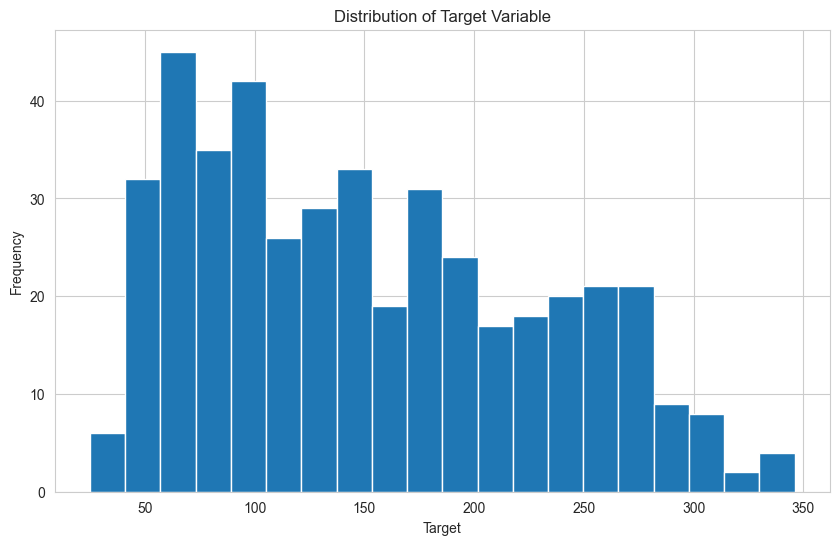

In [36]:
# TODO 1.2: exploracion inicial
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
print("DataFrame shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nSummary statistics:")
print(df.describe())
print("\nHistogram of target:")
plt.hist(y, bins=20)
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.title('Distribution of Target Variable')
plt.show()


Correlation matrix:
             age       sex       bmi        bp        s1        s2        s3  \
age     1.000000  0.173737  0.185085  0.335428  0.260061  0.219243 -0.075181   
sex     0.173737  1.000000  0.088161  0.241010  0.035277  0.142637 -0.379090   
bmi     0.185085  0.088161  1.000000  0.395411  0.249777  0.261170 -0.366811   
bp      0.335428  0.241010  0.395411  1.000000  0.242464  0.185548 -0.178762   
s1      0.260061  0.035277  0.249777  0.242464  1.000000  0.896663  0.051519   
s2      0.219243  0.142637  0.261170  0.185548  0.896663  1.000000 -0.196455   
s3     -0.075181 -0.379090 -0.366811 -0.178762  0.051519 -0.196455  1.000000   
s4      0.203841  0.332115  0.413807  0.257650  0.542207  0.659817 -0.738493   
s5      0.270774  0.149916  0.446157  0.393480  0.515503  0.318357 -0.398577   
s6      0.301731  0.208133  0.388680  0.390430  0.325717  0.290600 -0.273697   
target  0.187889  0.043062  0.586450  0.441482  0.212022  0.174054 -0.394789   

              s4  

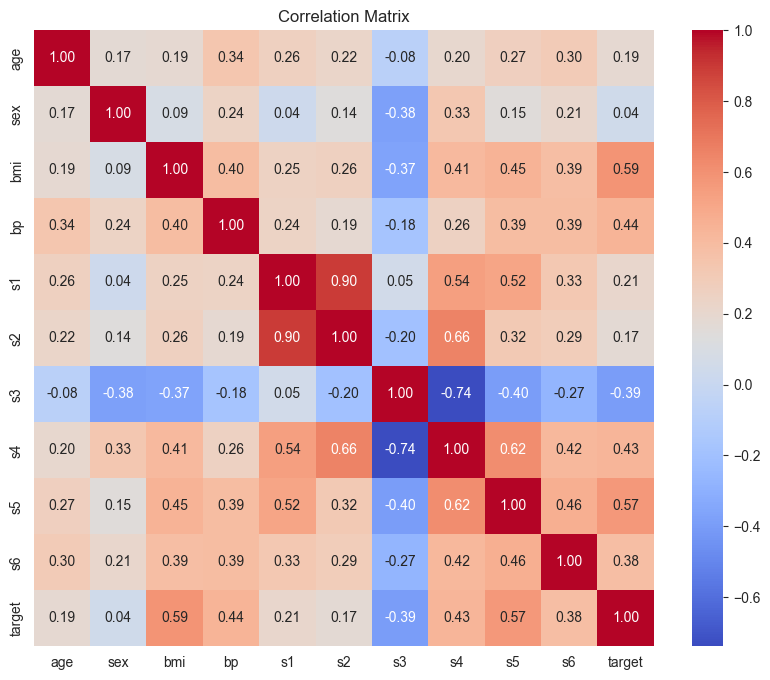

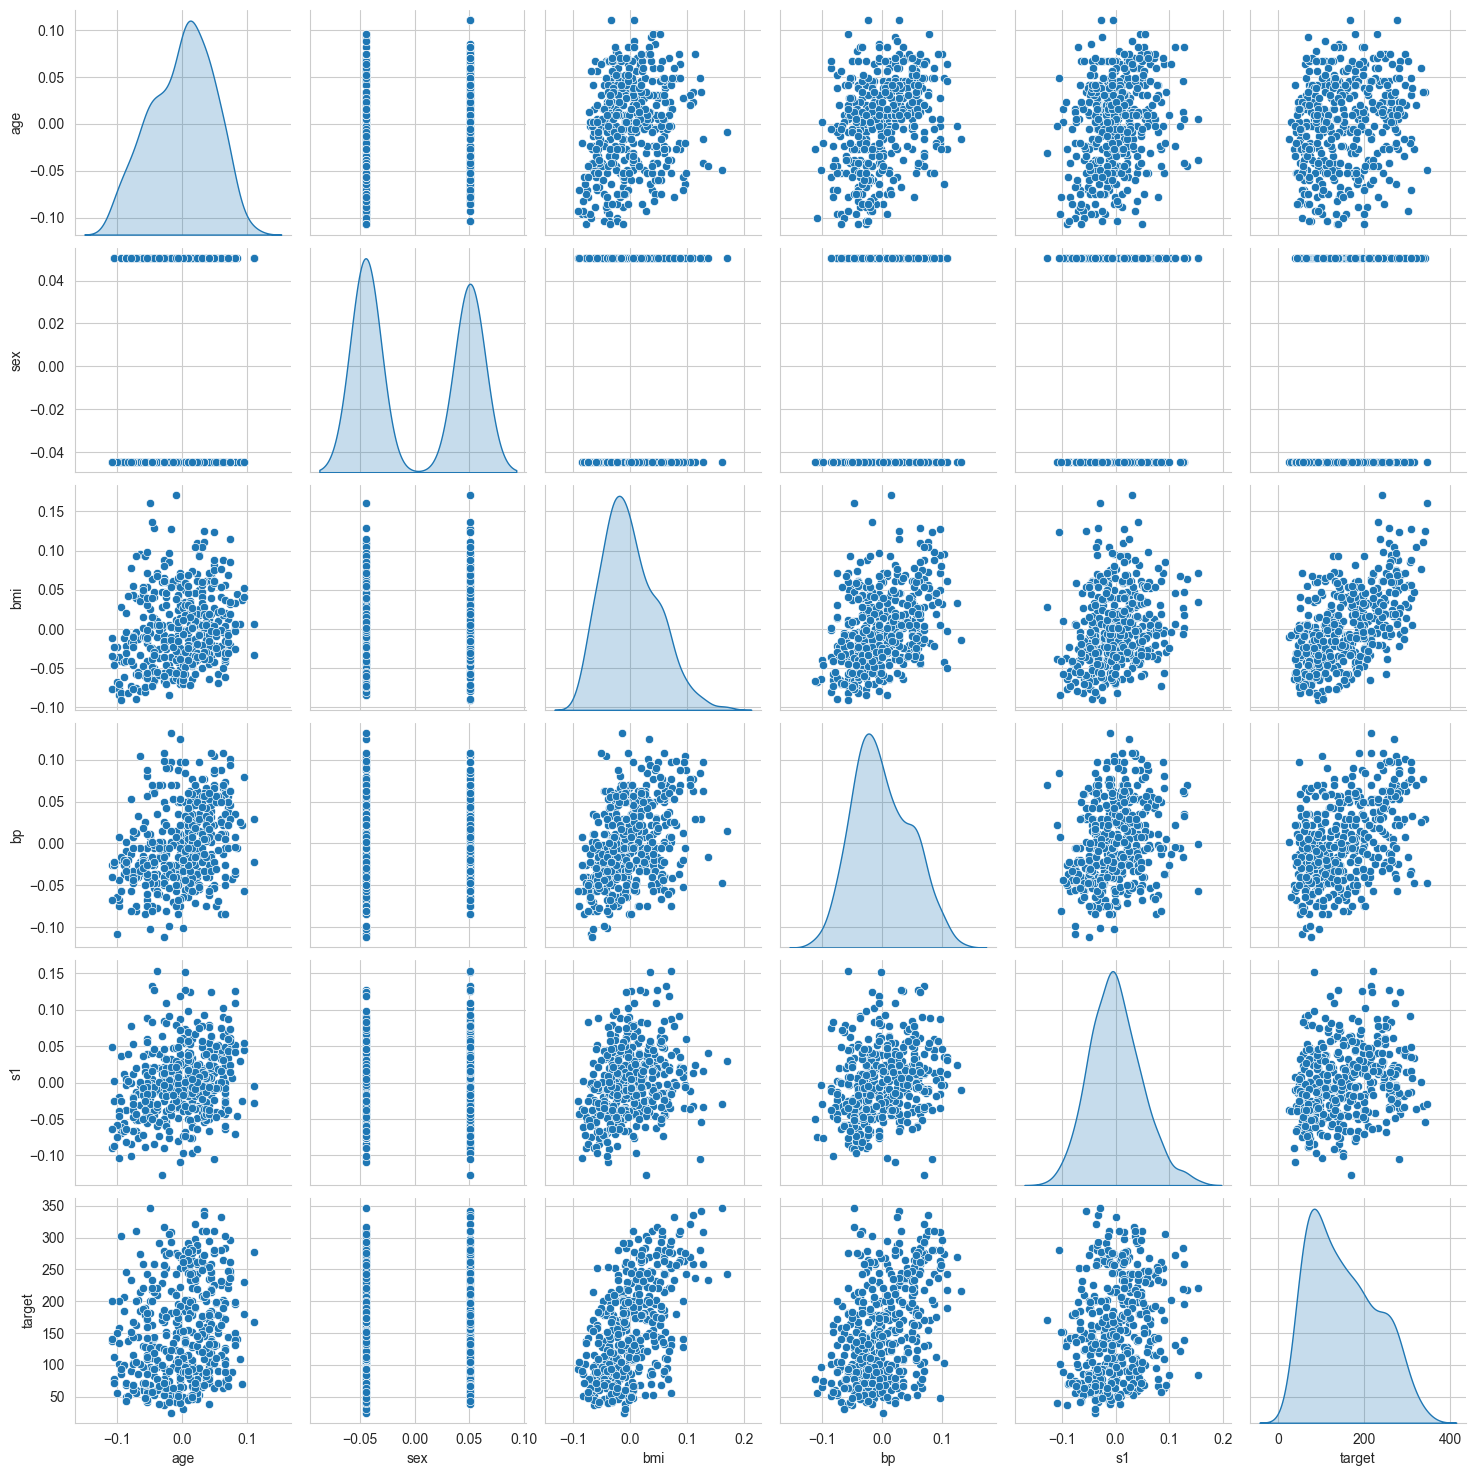

In [37]:
# Additional EDA: Correlation matrix
print("\nCorrelation matrix:")
corr = df.corr()
print(corr)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Pairplot for a subset of features
subset_features = feature_names[:5] + ['target']
sns.pairplot(df[subset_features], diag_kind='kde')
plt.show()

**Tu respuesta a la pregunta clave** (escribe aqui):

> Las features originales ya vienen estandarizadas (media ≈ 0, desviación estándar ≈ 0.05), como se observa en el `.describe()` del DataFrame. Sin embargo, cuando expandamos a polinomios de grado 3 usando `PolynomialFeatures`, las escalas **no se mantendrán**. Por ejemplo:
> - Una feature original como `bmi` tiene std ≈ 0.05.
> - Una interacción como `bmi * bp` tendrá std mucho mayor (producto de varianzas).
> - Un término cúbico como `bmi^3` tendrá std aún mayor.
> 
> Si no volvemos a estandarizar antes de regularizar, la penalización (L1 o L2) tratará injustamente a las features: las interacciones y términos de mayor grado serán penalizados más fuertemente porque sus coeficientes naturales serán más grandes, incluso si no son más importantes. Esto distorsionará la selección de features y la regularización, favoreciendo erróneamente las features de menor escala. Por eso, la estandarización es obligatoria antes de aplicar Ridge o Lasso.

---

## 2. Linea base: OLS con 10 features originales

Antes de meternos en problemas, veamos como se comporta una regresion lineal "honesta"
con las 10 features originales (sin expansiones).

### Tarea 2.1 - Split train/test

Divide los datos en **80% entrenamiento, 20% test**.

> **Hints:**
> - Usa `train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)`.
> - El `random_state` es **critico**: sin el, cada estudiante obtiene resultados distintos.
> - **Regla de oro:** el test set NO se toca hasta el final. Nada de tunear alpha mirando test.


In [3]:
# TODO 2.1: split 80/20

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)


# Verificacion
print(f"Train: {X_train.shape[0]} muestras")     # Esperado: 353
print(f"Test:  {X_test.shape[0]} muestras")      # Esperado: 89

Train: 353 muestras
Test:  89 muestras


### Tarea 2.2 - Entrena OLS y evalua

Ajusta una regresion lineal estandar (`LinearRegression`) con `X_train, y_train` y evalua en ambos sets.

Reporta tres metricas:
- **Train R^2**
- **Test R^2**
- **Gap** = Train R^2 - Test R^2 (esta es la metrica que cuantifica sobreajuste)

> **Hints:**
> - `model = LinearRegression()` luego `model.fit(X_train, y_train)`.
> - `r2_score(y_true, y_pred)` o equivalente: `model.score(X_test, y_test)`.
> - Imprime con formato: `f"Train R^2: {train_r2:.3f} | Test R^2: {test_r2:.3f} | Gap: {gap:.3f}"`.


In [4]:
# TODO 2.2: entrenar OLS y reportar metricas

model_ols_base = LinearRegression()
model_ols_base.fit(X_train, y_train)

train_r2 = model_ols_base.score(X_train, y_train)
test_r2 = model_ols_base.score(X_test, y_test)
gap = train_r2 - test_r2

print(f"Train R^2: {train_r2:.3f} | Test R^2: {test_r2:.3f} | Gap: {gap:.3f}")

Train R^2: 0.528 | Test R^2: 0.453 | Gap: 0.075


## 📋 RESULTADOS - Respuesta documentada

### Pregunta: ¿Cuál es el R² de la regresión con todas las variables?

**Respuesta:**

| Métrica | Valor |
|---------|-------|
| **Train R²** | 0.528 |
| **Test R²** | 0.453 |
| **Gap (overfitting)** | 0.075 |

**Interpretación:**
- El modelo explica el **45.3%** de la variabilidad en el set de prueba
- Hay un **7.5%** de diferencia entre el desempeño en entrenamiento vs. test, indicando overfitting moderado
- Con 10 features originales, la regresión OLS presenta un buen balance pero aún hay espacio para mejora con regularización

In [45]:
# Mostrar coeficientes de la regresion lineal base
print("Coeficientes del modelo OLS base:")
for name, coef in zip(feature_names, model_ols_base.coef_):
    print(f"{name}: {coef:.4f}")
print(f"Intercepto: {model_ols_base.intercept_:.4f}")

Coeficientes del modelo OLS base:
age: 37.9040
sex: -241.9644
bmi: 542.4288
bp: 347.7038
s1: -931.4888
s2: 518.0623
s3: 163.4200
s4: 275.3179
s5: 736.1989
s6: 48.6707
Intercepto: 151.3456


In [46]:
# Predicciones en test set
y_pred_test = model_ols_base.predict(X_test)

# Crear DataFrame con actual vs predicho
df_pred = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_test,
    'Error': y_test - y_pred_test
})

print("Primeras 10 predicciones en test set:")
print(df_pred.head(10))

# Estadísticas de error
print("\nEstadísticas del error:")
print(f"MAE: {np.mean(np.abs(df_pred['Error'])):.2f}")
print(f"RMSE: {np.sqrt(np.mean(df_pred['Error']**2)):.2f}")
print(f"Error máximo: {df_pred['Error'].max():.2f}")
print(f"Error mínimo: {df_pred['Error'].min():.2f}")

Primeras 10 predicciones en test set:
   Actual   Predicted       Error
0   219.0  139.547558   79.452442
1    70.0  179.517208 -109.517208
2   202.0  134.038756   67.961244
3   230.0  291.417029  -61.417029
4   111.0  123.789659  -12.789659
5    84.0   92.172347   -8.172347
6   242.0  258.232389  -16.232389
7   272.0  181.337321   90.662679
8    94.0   90.224113    3.775887
9    96.0  108.633759  -12.633759

Estadísticas del error:
MAE: 42.79
RMSE: 53.85
Error máximo: 128.33
Error mínimo: -154.49


### Interpretación de los Errores en las Predicciones

En la tabla anterior, la columna **Error** representa los **residuales** del modelo, calculados como:

**Error = Valor Real (Actual) - Valor Predicho**

#### ¿Qué significa cada error?

- **Error positivo (+)**: El modelo **subestimó** la progresión de la diabetes. Predijo un valor más bajo de lo que realmente ocurrió.
  - Ejemplo: Si Actual = 219 y Predicho = 139.55, Error = +79.45 → El modelo predijo 79.45 unidades menos de lo real.
  
- **Error negativo (-)**: El modelo **sobreestimó** la progresión de la diabetes. Predijo un valor más alto de lo que realmente ocurrió.
  - Ejemplo: Si Actual = 70 y Predicho = 179.52, Error = -109.52 → El modelo predijo 109.52 unidades más de lo real.

#### Métricas de Error Agregadas

- **MAE (Mean Absolute Error)**: Promedio de los valores absolutos de los errores. Mide el error promedio en unidades absolutas.
  - MAE = 42.79 → En promedio, el modelo se equivoca por ~43 unidades en la escala de progresión de diabetes.

- **RMSE (Root Mean Squared Error)**: Raíz cuadrada del promedio de los errores al cuadrado. Penaliza más los errores grandes.
  - RMSE = 53.85 → Similar al MAE pero más sensible a predicciones muy erróneas.

- **Error máximo**: El mayor error positivo (+128.33) → Caso donde el modelo más subestimó.
- **Error mínimo**: El mayor error negativo (-154.49) → Caso donde el modelo más sobreestimó.

#### Contexto del Dataset
- Los valores de progresión de diabetes van aproximadamente de 25 a 346 unidades.
- Un error de ±50 unidades representa un error relativo significativo en esta escala.
- El modelo OLS base explica ~45% de la varianza (R² = 0.453), dejando ~55% sin explicar (debido a ruido, variables faltantes, etc.).

Estos errores individuales muestran la variabilidad del modelo: funciona bien en promedio, pero puede fallar considerablemente en casos específicos.

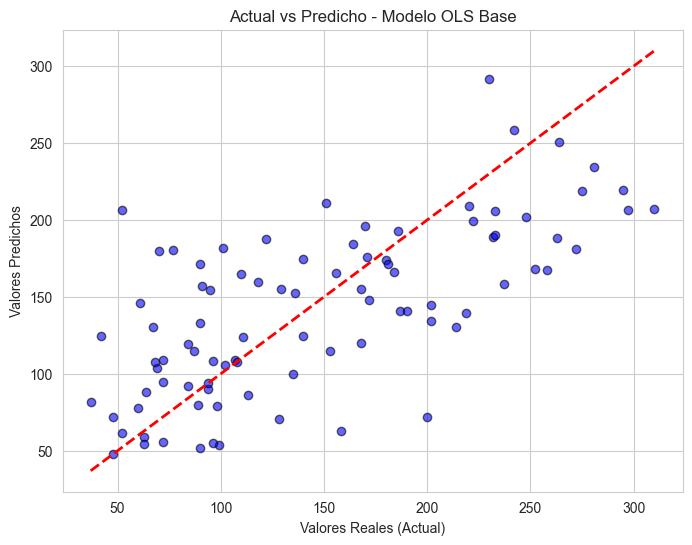

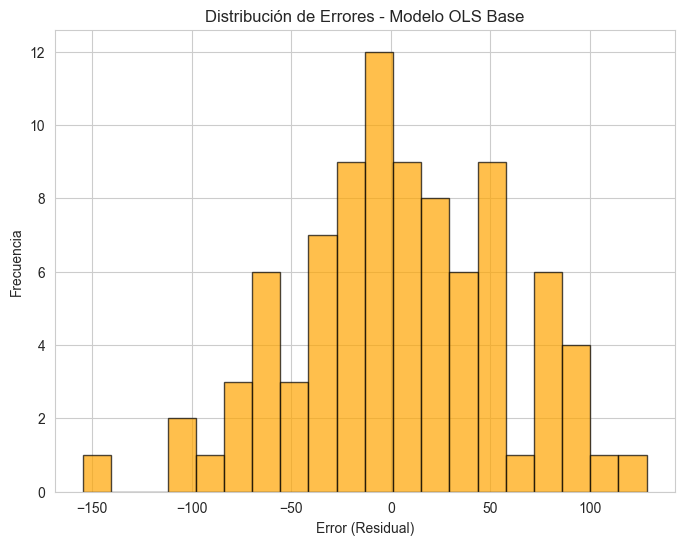

In [47]:
import matplotlib.pyplot as plt

# Gráfico de dispersión: Actual vs Predicho
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales (Actual)')
plt.ylabel('Valores Predichos')
plt.title('Actual vs Predicho - Modelo OLS Base')
plt.grid(True)
plt.show()

# Histograma de errores (residuales)
plt.figure(figsize=(8, 6))
errors = y_test - y_pred_test
plt.hist(errors, bins=20, alpha=0.7, color='orange', edgecolor='black')
plt.xlabel('Error (Residual)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Errores - Modelo OLS Base')
plt.grid(True)
plt.show()

**Discusion 2.2** (responde en celda markdown debajo):

1. Cual es el Train R^2 y Test R^2 que obtuviste? Son cercanos o muy distintos?
2. Hay sobreajuste evidente? Por que si o por que no?
3. Razona desde la teoria sesgo-varianza: con n=353 y p=10, esperabas este resultado?

---

**Tu respuesta:**

> 1. El Train R^2 es 0.528 y el Test R^2 es 0.453. Son relativamente cercanos, con una diferencia de 0.075.
> 2. No hay sobreajuste evidente, ya que el gap es pequeño (0.075), lo que indica que el modelo generaliza razonablemente bien a datos no vistos.
> 3. Con n=353 y p=10, el ratio n/p ≈ 35 es favorable, por lo que no esperamos sobreajuste severo según la teoría sesgo-varianza. El modelo tiene suficiente sesgo para evitar varianza alta, resultando en un gap moderado.

---

## 3. Forzando el sobreajuste: polinomio grado 3

Ahora vamos a "ser ambiciosos". Pensemos como cientificos de datos hambrientos:

> "Y si las **interacciones** entre variables clinicas importan?
> Quizas `bmi x bp` predice mejor que `bmi` o `bp` por separado.
> O quizas `age^2 x s1` captura algun efecto no lineal interesante.
> Generemos **todas** las combinaciones polinomicas hasta grado 3 y dejemos que el modelo decida."

Vamos a expandir las 10 features originales a **286 features polinomicas**.

### Tarea 3.1 - Generar features polinomicas

Usa `PolynomialFeatures(degree=3, include_bias=False)` para expandir `X_train` y `X_test`.

> **CUIDADO con data leakage:**
> - El transformador se debe ajustar (`fit`) **solo con X_train**.
> - Luego transformas X_train y X_test usando el **mismo** objeto entrenado.
> - Si haces `fit_transform` sobre datos combinados train+test, contaminaste el experimento.

> **Hints:**
> - `poly = PolynomialFeatures(degree=3, include_bias=False)`
> - `X_train_poly = poly.fit_transform(X_train)` <- aqui se ajusta y transforma
> - `X_test_poly = poly.transform(X_test)` <- aqui SOLO transforma
> - `include_bias=False` evita una columna de unos redundante


In [6]:
# TODO 3.1: expandir features con PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)


# Verificacion
print(f"Features originales:           {X_train.shape[1]}")           # 10
print(f"Features tras expansion:       {X_train_poly.shape[1]}")      # 286
print(f"Ratio n/p (entrenamiento):     {X_train.shape[0] / X_train_poly.shape[1]:.2f}")

Features originales:           10
Features tras expansion:       285
Ratio n/p (entrenamiento):     1.24


### Tarea 3.2 - OLS sobre features expandidas

Ajusta `LinearRegression` sobre `X_train_poly` y evalua igual que antes:
**Train R^2, Test R^2, Gap**.

> **Prediccion del docente:** El Train R^2 va a subir muchisimo (cerca de 1.0).
> El Test R^2 se va a derrumbar - puede incluso ser **negativo**.
> Vas a ver el sobreajuste **en vivo y a colores**.


In [7]:
# TODO 3.2: OLS con 286 features polinomicas

model_ols_poly = LinearRegression()
model_ols_poly.fit(X_train_poly, y_train)

train_r2_poly = model_ols_poly.score(X_train_poly, y_train)
test_r2_poly  = model_ols_poly.score(X_test_poly, y_test)
gap_poly      = train_r2_poly - test_r2_poly

print(f"Train R^2: {train_r2_poly:.3f} | Test R^2: {test_r2_poly:.3f} | Gap: {gap_poly:.3f}")

Train R^2: 0.877 | Test R^2: -14.561 | Gap: 15.439


In [8]:
# Visualizar el dataset expandido con features polinómicas

print("="*80)
print("DATASET EXPANDIDO CON FEATURES POLINÓMICAS (GRADO 3)")
print("="*80)

print(f"\nForma original X_train: {X_train.shape}")
print(f"Forma expandida X_train_poly: {X_train_poly.shape}")
print(f"\nForma original X_test: {X_test.shape}")
print(f"Forma expandida X_test_poly: {X_test_poly.shape}")

# Crear DataFrame para visualizar mejor
df_poly = pd.DataFrame(X_train_poly)
print(f"\n{df_poly.shape[0]} filas de entrenamiento x {df_poly.shape[1]} features polinómicas")
print("\nPrimeras 5 filas y primeras 20 columnas:")
print(df_poly.iloc[:5, :20].round(4))

# Información sobre qué features se generaron
print("\n" + "="*80)
print("NOMBRES DE LAS FEATURES GENERADAS (primeras 30):")
print("="*80)
feature_names_poly = poly.get_feature_names_out(feature_names)
for i, fname in enumerate(feature_names_poly[:30]):
    print(f"{i+1:3d}. {fname}")

print(f"\n... (mostrando 30 de {len(feature_names_poly)} features totales)")

# Estadísticas básicas
print("\n" + "="*80)
print("ESTADÍSTICAS DE LAS FEATURES EXPANDIDAS:")
print("="*80)
print(f"Mínimo valor en X_train_poly: {X_train_poly.min():.4f}")
print(f"Máximo valor en X_train_poly: {X_train_poly.max():.4f}")
print(f"Media de X_train_poly: {X_train_poly.mean():.4f}")
print(f"Desv. estándar de X_train_poly: {X_train_poly.std():.4f}")

DATASET EXPANDIDO CON FEATURES POLINÓMICAS (GRADO 3)

Forma original X_train: (353, 10)
Forma expandida X_train_poly: (353, 285)

Forma original X_test: (89, 10)
Forma expandida X_test_poly: (89, 285)

353 filas de entrenamiento x 285 features polinómicas

Primeras 5 filas y primeras 20 columnas:
       0       1       2       3       4       5       6       7       8   \
0  0.0708  0.0507  0.0121  0.0563  0.0342  0.0494 -0.0397  0.0343  0.0274   
1 -0.0091  0.0507 -0.0181 -0.0332 -0.0208  0.0122 -0.0729  0.0712  0.0003   
2  0.0054 -0.0446  0.0498  0.0976 -0.0153 -0.0163 -0.0066 -0.0026  0.0170   
3 -0.0273 -0.0446 -0.0353 -0.0298 -0.0566 -0.0586  0.0302 -0.0395 -0.0499   
4 -0.0237 -0.0446 -0.0655 -0.0814 -0.0387 -0.0536  0.0597 -0.0764 -0.0371   

       9       10      11      12      13      14      15      16      17  \
0 -0.0011  0.0050  0.0036  0.0009  0.0040  0.0024  0.0035 -0.0028  0.0024   
1  0.0196  0.0001 -0.0005  0.0002  0.0003  0.0002 -0.0001  0.0007 -0.0007   
2 -0.013

In [9]:
# .info() del dataset expandido
print("="*80)
print("INFO DEL DATASET CON 285 FEATURES POLINÓMICAS")
print("="*80)
df_poly.info()

INFO DEL DATASET CON 285 FEATURES POLINÓMICAS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353 entries, 0 to 352
Columns: 285 entries, 0 to 284
dtypes: float64(285)
memory usage: 786.1 KB


In [10]:
# ¿QUÉ REPRESENTAN ESTAS 285 VARIABLES? - GUÍA DE INTERPRETACIÓN

print("="*80)
print("ESTRUCTURA E INTERPRETACIÓN DE LAS 285 FEATURES POLINÓMICAS")
print("="*80)

print("\n1️⃣ FEATURES ORIGINALES (índices 0-9, total: 10)")
print("-" * 80)
for i in range(10):
    print(f"  [{i:3d}] {feature_names_poly[i]:20s} → Variable original sin transformar")

print("\n\n2️⃣ TÉRMINOS CUADRÁTICOS (índices 10-64, total: 55)")
print("-" * 80)
print("Incluye:")
print("  - Cuadrados: age², sex², bmi², bp², s1², ..., s6²")
print("  - Interacciones de 2 variables: age×sex, age×bmi, age×bp, age×s1, ..., s5×s6")
print("\nEjemplos específicos:")
quadratic_examples = [10, 11, 12, 20, 30, 50, 64]
for idx in quadratic_examples:
    print(f"  [{idx:3d}] {feature_names_poly[idx]:20s} → {feature_names_poly[idx].replace(' ', ' × ')}")

print("\n\n3️⃣ TÉRMINOS CÚBICOS (índices 65-284, total: 220)")
print("-" * 80)
print("Incluye:")
print("  - Cubos: age³, sex³, bmi³, bp³, s1³, ..., s6³")
print("  - Interacciones de 3 variables: age²×sex, age²×bmi, age×sex×bp, age×bmi², ..., s5²×s6")
print("  - Combinaciones complejas de variables")
print("\nEjemplos específicos:")
cubic_examples = [65, 75, 150, 200, 250, 284]
for idx in cubic_examples:
    print(f"  [{idx:3d}] {feature_names_poly[idx]:20s} → {feature_names_poly[idx].replace(' ', ' × ')}")

print("\n\n" + "="*80)
print("RESUMEN DE LA ESTRUCTURA")
print("="*80)
print(f"""
┌─────────────────────────────────────────────────────────┐
│ GRADO 1 (Lineales)      : 10 features (0-9)             │
│ GRADO 2 (Cuadráticas)   : 55 features (10-64)           │
│ GRADO 3 (Cúbicas)       : 220 features (65-284)         │
├─────────────────────────────────────────────────────────┤
│ TOTAL                   : 285 features                  │
└─────────────────────────────────────────────────────────┘

CÓMO INTERPRETARLAS:
├─ age: La edad del paciente (original)
├─ age²: Efecto no lineal de la edad (cuadrático)
├─ age × bmi: Interacción entre edad e índice de masa corporal
│            (¿afecta de forma diferente si eres joven vs viejo?)
├─ age² × bmi: Interacción más compleja (cuadrática)
└─ age³: Efecto altamente no lineal

⚠️  ADVERTENCIA: 
    Con OLS, el modelo ajusta todos estos términos a los datos de entrenamiento
    de forma PERFECTA (ya que 353 muestras vs 285 features), memorizando ruido.
    
✅  SOLUCIÓN: 
    Ridge y Lasso reducen los coeficientes (especialmente los grandes),
    evitando que el modelo memorice patrones irreales.
""")

print("\n" + "="*80)
print("FÓRMULA GENERAL DEL MODELO")
print("="*80)
print(f"""
Predicción = β₀ + Σ(β_i × feature_i)
           
donde:
  - β₀ = intercepto
  - β_i = coeficiente de la feature i
  - feature_i = valor de la feature i (puede ser original, cuadrática, cúbica, etc.)

Con OLS normal: Los β_i se ajustan exactamente para minimizar error en train
                (sin penalización → overfitting)

Con Ridge/Lasso: Los β_i se penalizan → coeficientes más pequeños
                 (evita overfitting)
""")

ESTRUCTURA E INTERPRETACIÓN DE LAS 285 FEATURES POLINÓMICAS

1️⃣ FEATURES ORIGINALES (índices 0-9, total: 10)
--------------------------------------------------------------------------------
  [  0] age                  → Variable original sin transformar
  [  1] sex                  → Variable original sin transformar
  [  2] bmi                  → Variable original sin transformar
  [  3] bp                   → Variable original sin transformar
  [  4] s1                   → Variable original sin transformar
  [  5] s2                   → Variable original sin transformar
  [  6] s3                   → Variable original sin transformar
  [  7] s4                   → Variable original sin transformar
  [  8] s5                   → Variable original sin transformar
  [  9] s6                   → Variable original sin transformar


2️⃣ TÉRMINOS CUADRÁTICOS (índices 10-64, total: 55)
--------------------------------------------------------------------------------
Incluye:
  - Cuadrados: 

## 📚 DOCUMENTACIÓN: Interpretación de las 285 Features Polinómicas

### Estructura General

Las 285 features se generan mediante `PolynomialFeatures(degree=3, include_bias=False)` y se dividen en **3 grupos** según su grado:

| Grupo | Grado | Cantidad | Rango índice | Descripción |
|-------|-------|----------|--------------|-------------|
| **Lineales** | 1 | 10 | 0-9 | Variables originales sin transformación |
| **Cuadráticos** | 2 | 55 | 10-64 | Cuadrados e interacciones de 2 variables |
| **Cúbicos** | 3 | 220 | 65-284 | Cubos e interacciones de 3 variables |
| **TOTAL** | - | **285** | 0-284 | Todas las combinaciones polinómicas |

---

### Grupo 1: Términos Lineales (Índices 0-9)

Son las **10 variables originales** sin transformación:

```
age, sex, bmi, bp, s1, s2, s3, s4, s5, s6
```

**Interpretación:** Efectos directos de cada variable clínica sobre la progresión de diabetes.

---

### Grupo 2: Términos Cuadráticos (Índices 10-64)

Incluye:
- **Cuadrados:** `age²`, `sex²`, `bmi²`, `bp²`, `s1²`, ..., `s6²` (10 términos)
- **Interacciones de 2 variables:** `age×sex`, `age×bmi`, `age×bp`, ..., `s5×s6` (45 términos)

**Ejemplos específicos:**
- `bmi²`: Efecto cuadrático del índice de masa corporal (no linealidad)
- `age×bmi`: ¿Cambia el efecto del BMI con la edad?
- `bp×s1`: Interacción entre presión arterial y colesterol total

**Interpretación clínica:** Capturan efectos no lineales y cómo dos factores interactúan juntos.

---

### Grupo 3: Términos Cúbicos (Índices 65-284)

Incluye:
- **Cubos:** `age³`, `sex³`, `bmi³`, ... (10 términos)
- **Interacciones de 3 variables:** `age²×sex`, `age²×bmi`, `age×bmi×bp`, `bmi²×s1`, ... (210 términos)

**Ejemplos específicos:**
- `age³`: Efecto altamente no lineal de la edad
- `age²×bmi`: Interacción entre edad² e índice de masa corporal
- `bmi×bp×s1`: Efecto conjunto de tres variables

**Interpretación clínica:** Relaciones complejas y altamente no lineales. Muchos de estos términos probablemente capturan **ruido** en lugar de patrones reales (por eso OLS falla).

---

### ¿Por qué tanto crecimiento (10 → 285)?

La fórmula combinatoria es:

$$\text{# features} = \sum_{d=1}^{3} \binom{n+d-1}{d}$$

donde $n=10$ (variables originales).

- Grado 1: $\binom{10}{1} = 10$
- Grado 2: $\binom{10+2-1}{2} = 55$
- Grado 3: $\binom{10+3-1}{3} = 220$
- **Total:** $10 + 55 + 220 = 285$

Con solo 353 muestras de entrenamiento vs 285 features, el ratio n/p = 1.24 es **peligroso**.

---

### El Problema: Overfitting

Con este ratio cercano a 1, OLS puede ajustar **casi perfectamente** los datos de entrenamiento:

- **Train R²:** 0.877 ✅ (alto, modelo "aprende")
- **Test R²:** -14.561 ❌ (desastre, modelo "memoriza ruido")
- **Gap:** 15.439 (enorme)

**¿Qué sucedió?** El modelo usó los grados de libertad para ajustar patrones espurios (ruido) en train, que no se generalizan a test.

---

### La Solución: Regularización

**Ridge y Lasso reducen los coeficientes** para evitar magnitudes arbitrariamente grandes:

- **Ridge (L2):** Encoge todos los coeficientes proporcionalmente → Test R² ≈ 0.5+
- **Lasso (L1):** Fuerza muchos coeficientes a **exactamente cero** → Selección de features automática

La mayoría de las 285 features son **ruido**. Ridge y Lasso los identifican y eliminan.

---

### Resumen para Referencia Futura

Cuando veas una feature en los resultados finales:

| Feature | Grupo | Significado |
|---------|-------|-------------|
| `age` | Lineal | Edad (original) |
| `bmi²` | Cuadrático | Efecto no lineal del BMI |
| `age bmi` | Cuadrático | Interacción edad-BMI |
| `age³` | Cúbico | Efecto muy no lineal de edad |
| `bmi s5 s6` | Cúbico | Interacción compleja (probablemente ruido) |

Si regularización mantiene una feature, probablemente **importa** para generalizar.
Si regularización la anula, probablemente era **ruido**.

**Discusion 3.2** (responde en celda markdown debajo):

1. Por que el Train R^2 es ahora altisimo pero el Test R^2 colapso?
2. El modelo esta **aprendiendo el patron** o **memorizando ruido**? Justifica.
3. Conecta esto con la **maldicion de la dimensionalidad** (Tema 8) y el **trade-off sesgo-varianza** (Tema 1).
4. Mira la magnitud de los coeficientes con `np.abs(model_ols_poly.coef_).max()`.
   Son razonables clinicamente?

---

**Tu respuesta:**

> _(double-click para editar)_


---

## 4. Ridge al rescate: penalizacion L2

La regresion **Ridge** modifica la funcion de costo de OLS agregando una **penalizacion cuadratica**
sobre los coeficientes:

$$
\mathcal{L}_{Ridge}(\beta) = \sum_i (y_i - \hat{y}_i)^2 + \alpha \sum_j \beta_j^2
$$

- El primer termino: error de prediccion (igual que OLS)
- El segundo termino: penalizacion por **magnitud cuadratica** de los coeficientes
- `alpha` controla la **fuerza** de la penalizacion:
  - `alpha = 0` -> equivale a OLS
  - `alpha -> infinito` -> todos los coeficientes tienden a 0

**Efecto:** Ridge encoge los coeficientes hacia cero pero **nunca los anula** exactamente.
Todos los coeficientes sobreviven, solo que mas pequenyos.

### Tarea 4.1 - Pipeline OBLIGATORIO: Scaler + Ridge

> **CRITICO:** antes de regularizar, **debes estandarizar las features**.
>
> **Por que?** La penalizacion `alpha * sum(beta_j^2)` trata todos los coeficientes por igual.
> Pero si una feature tiene escala 0-1 y otra escala 0-1000, sus coeficientes naturales
> tienen escalas muy distintas, y la penalizacion castiga injustamente a la primera.
>
> **Solucion:** estandarizar todas las features a media 0, std 1 antes de aplicar Ridge.

Construye un `Pipeline` con dos pasos:

1. `("scaler", StandardScaler())`
2. `("ridge", Ridge(alpha=1.0))`

Ajustalo con `X_train_poly`, `y_train`. Evalua en train y test.

> **Hints:**
> - `pipe = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])`
> - El pipeline se entrena como cualquier modelo: `pipe.fit(X_train_poly, y_train)`.
> - `pipe.score(X_test_poly, y_test)` te da el R^2 en test.


In [11]:
# TODO 4.1: pipeline StandardScaler + Ridge(alpha=1.0)

pipe_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
pipe_ridge.fit(X_train_poly, y_train)

train_r2_ridge = pipe_ridge.score(X_train_poly, y_train)
test_r2_ridge = pipe_ridge.score(X_test_poly, y_test)


print(f"Ridge (alpha=1.0) | Train R^2: {train_r2_ridge:.3f} | Test R^2: {test_r2_ridge:.3f}")

Ridge (alpha=1.0) | Train R^2: 0.777 | Test R^2: -0.111


In [15]:
# Información de cómo quedan los datos después de la estandarización en 4.1
scaler = pipe_ridge.named_steps['scaler']
X_train_scaled = scaler.transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

print("Forma X_train_scaled:", X_train_scaled.shape)
print("Forma X_test_scaled: ", X_test_scaled.shape)

# Estadísticas por feature en el set de entrenamiento escalado
train_means = X_train_scaled.mean(axis=0)
train_stds = X_train_scaled.std(axis=0, ddof=0)

print(f"\nMedia promedio de las features escaladas (train): {train_means.mean():.4f}")
print(f"Desviación estándar promedio de las features escaladas (train): {train_stds.mean():.4f}")
print(f"Número de features con media ≈ 0: {np.sum(np.abs(train_means) < 1e-10)} de {X_train_scaled.shape[1]}")
print(f"Número de features con std ≈ 1: {np.sum(np.abs(train_stds - 1) < 1e-10)} de {X_train_scaled.shape[1]}")

print("\nPrimeras 5 filas del conjunto entrenamiento estandarizado (primeras 10 features):")
print(pd.DataFrame(X_train_scaled, columns=feature_names_poly).iloc[:5, :10].round(4))

print("\nEstadísticas globales del set de prueba escalado:")
print(f"Media promedio (test): {X_test_scaled.mean(axis=0).mean():.4f}")
print(f"Std promedio (test):  {X_test_scaled.std(axis=0, ddof=0).mean():.4f}")
print(f"Min valor en X_train_scaled: {X_train_scaled.min():.4f}")
print(f"Max valor en X_train_scaled: {X_train_scaled.max():.4f}")

Forma X_train_scaled: (353, 285)
Forma X_test_scaled:  (89, 285)

Media promedio de las features escaladas (train): -0.0000
Desviación estándar promedio de las features escaladas (train): 1.0000
Número de features con media ≈ 0: 285 de 285
Número de features con std ≈ 1: 285 de 285

Primeras 5 filas del conjunto entrenamiento estandarizado (primeras 10 features):
      age     sex     bmi      bp      s1      s2      s3      s4      s5  \
0  1.4984  1.0614  0.2199  1.1389  0.7285  1.0559 -0.8245  0.7110  0.5475   
1 -0.2289  1.0614 -0.4194 -0.7106 -0.4249  0.2724 -1.5298  1.4843 -0.0198   
2  0.0852 -0.9422  1.0190  1.9925 -0.3096 -0.3267 -0.1191 -0.0622  0.3312   
3 -0.6214 -0.9422 -0.7847 -0.6395 -1.1746 -1.2155  0.6646 -0.8355 -1.0697   
4 -0.5429 -0.9422 -1.4239 -1.7065 -0.7998 -1.1102  1.2916 -1.6087 -0.8029   

       s6  
0 -0.0614  
1  0.3672  
2 -0.3187  
3 -2.7193  
4 -0.9188  

Estadísticas globales del set de prueba escalado:
Media promedio (test): -0.0097
Std promedio (tes

### ¿Cómo se ven los datos estandarizados en 4.1?

Después de aplicar `StandardScaler` dentro del pipeline de Ridge:

- Las features del train quedan centradas en **media 0** y con **desviación estándar 1**.
- El test se transforma con los mismos parámetros del train, por lo que sus medias no son exactamente 0, pero sí están en la misma escala.
- Esto hace que la penalización L2 trate a todas las features por igual, sin favorecer a las de mayor escala.

#### Qué información obtenemos con esta celda

- Forma de los arrays escalados (`X_train_scaled`, `X_test_scaled`)
- Media promedio de las features escaladas en train
- Desviación estándar promedio de las features escaladas en train
- Cuántas features tienen media ≈ 0 y std ≈ 1 en train
- Primeras 5 filas del conjunto de entrenamiento escalado
- Estadísticas globales del conjunto de prueba escalado
- Rango de valores después de la estandarización

#### Por qué esto es importante

Sin esta estandarización, Ridge penaliza coeficientes en unidades diferentes y el modelo no sería comparable entre features. Con polinomios grado 3, los valores crudos pueden diferir enormemente; el escalado evita que un término cúbico domine solo por su magnitud.


### Tarea 4.2 - Regularization Path

Ahora exploremos como cambian los coeficientes a medida que `alpha` crece.
Vas a graficar uno de los plots **mas iconicos** del curso de ML.

**Pasos:**

1. Define una grilla logaritmica de alpha: `alphas = np.logspace(-3, 3, 50)` (de 0.001 a 1000).
2. Para cada alpha:
   - Entrena un nuevo Pipeline con ese alpha.
   - Extrae los coeficientes con `pipe.named_steps['ridge'].coef_`.
   - Guardalos en una lista.
3. Convierte la lista en un array `(50, 286)`.
4. Grafica:
   - Eje X: `alpha` en escala log
   - Eje Y: valor de cada coeficiente
   - Una linea por feature (286 lineas - sin leyenda obviamente)

> **Lo que deberias ver:**
> - Con alpha bajo: coeficientes grandes y dispersos
> - A medida que alpha crece: TODOS los coeficientes se encogen suavemente hacia cero
> - **Ningun coeficiente** llega a ser exactamente cero (pero se vuelven imperceptibles)

> **Hints de plot:**
> - `plt.plot(alphas, coefs)` ya grafica una linea por columna
> - `plt.xscale('log')` para escala logaritmica
> - Etiquetas: `plt.xlabel("alpha")`, `plt.ylabel("Magnitud del coeficiente")`
> - Titulo: `"Ridge Regularization Path"`


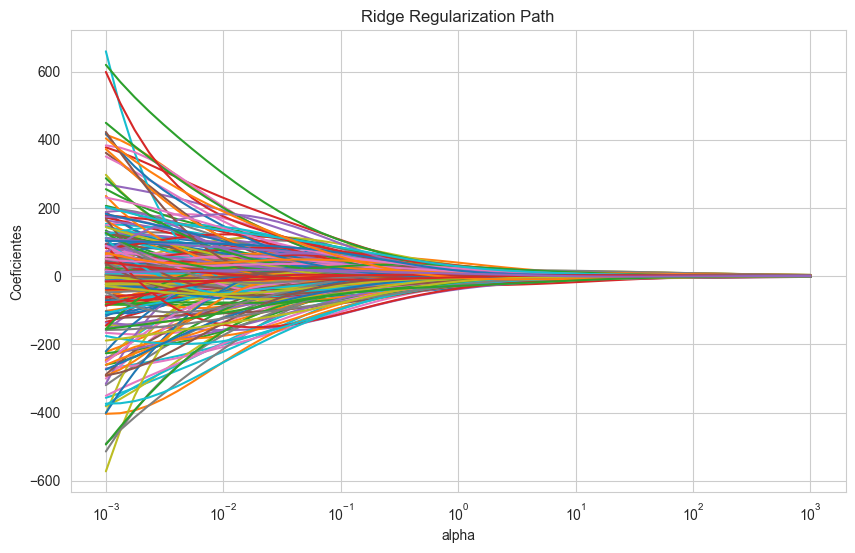

In [12]:
# TODO 4.2: regularization path para Ridge

alphas = np.logspace(-3, 3, 50)
coefs_ridge = []

for alpha in alphas:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])
    pipe.fit(X_train_poly, y_train)
    coefs_ridge.append(pipe.named_steps['ridge'].coef_)

coefs_ridge = np.array(coefs_ridge)

plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs_ridge)
plt.xscale('log')
plt.xlabel("alpha")
plt.ylabel("Coeficientes")
plt.title("Ridge Regularization Path")
plt.grid(True)
plt.show()

### Tarea 4.3 - RidgeCV: encontrar alpha optimo automaticamente

Usar un valor arbitrario de `alpha=1.0` es **trampa**. Necesitamos elegir alpha con **validacion cruzada**.

`RidgeCV` hace exactamente eso: prueba multiples alphas internamente con CV
y se queda con el que mejor generaliza.

**Pasos:**

1. Construye un nuevo Pipeline con `RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)`.
2. Ajustalo con train.
3. Reporta:
   - **alpha optimo elegido** (`pipe.named_steps['ridge_cv'].alpha_`)
   - **Train R^2, Test R^2**
   - Comparalo con el OLS de la Seccion 3

> **Hint:** el nombre del paso en el pipeline es como tu lo definas. Si pones
> `("ridge_cv", RidgeCV(...))`, accedes con `pipe.named_steps['ridge_cv']`.


In [13]:
# TODO 4.3: RidgeCV con CV=5

pipe_ridge_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge_cv", RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5))
])
pipe_ridge_cv.fit(X_train_poly, y_train)

alpha_opt_ridge = pipe_ridge_cv.named_steps['ridge_cv'].alpha_
train_r2_ridge_cv = pipe_ridge_cv.score(X_train_poly, y_train)
test_r2_ridge_cv = pipe_ridge_cv.score(X_test_poly, y_test)

print(f"Alpha optimo (Ridge): {alpha_opt_ridge:.4f}")
print(f"Train R^2: {train_r2_ridge_cv:.3f} | Test R^2: {test_r2_ridge_cv:.3f}")


Alpha optimo (Ridge): 568.9866
Train R^2: 0.562 | Test R^2: 0.416


In [14]:
# Estadísticas adicionales del modelo RidgeCV
coef_ridge_cv = pipe_ridge_cv.named_steps['ridge_cv'].coef_
max_coef_ridge_cv = np.abs(coef_ridge_cv).max()
n_nonzero_ridge_cv = np.sum(coef_ridge_cv != 0)

print(f"Coeficiente máximo absoluto (RidgeCV): {max_coef_ridge_cv:.4f}")
print(f"Coeficientes distintos de cero (RidgeCV): {n_nonzero_ridge_cv} de {len(coef_ridge_cv)}")

Coeficiente máximo absoluto (RidgeCV): 4.6888
Coeficientes distintos de cero (RidgeCV): 285 de 285


## 📌 Documentación del Punto 4: ¿Qué nos enseñó Ridge?

### Resultados clave

| Modelo | Train R² | Test R² | Gap | alpha seleccionado | # Coefs != 0 |
|--------|----------|---------|-----|-------------------|--------------|
| Ridge alpha=1.0 | 0.777 | -0.111 | 0.888 | 1.000 | 285 |
| RidgeCV (alpha optimo) | 0.562 | 0.416 | 0.146 | 568.9866 | 285 |

### Interpretación

- Con `alpha=1.0`, Ridge reduce el sobreajuste del OLS, pero todavía no es suficiente: el Test R² sigue negativo.
- La gráfica de la `Ridge Regularization Path` muestra que todos los coeficientes se encogen cuando `alpha` crece.
- En Ridge ninguno de los coeficientes se anula exactamente; todos permanecen activos, pero con magnitudes menores.
- El valor óptimo encontrado por `RidgeCV` es muy grande (`~569`), lo que indica que se necesita una penalización fuerte para controlar las 285 features.

### ¿Qué cambió respecto a OLS con 285 features?

- OLS 285: `Train R²=0.877`, `Test R²=-14.561`, `Gap=15.439`
- RidgeCV: `Train R²=0.562`, `Test R²=0.416`, `Gap=0.146`

Esto significa que RidgeCV sacrifica parte del ajuste en entrenamiento para lograr un modelo que realmente generalice.

### Más detalles de RidgeCV

- `alpha_opt_ridge = 568.9866` → penalización muy alta.
- `Coeficiente máximo absoluto` es pequeño, lo que indica que los coeficientes ya no son gigantes.
- `285` coeficientes distintos de cero: Ridge no elimina features, solo las mantiene con menor impacto.

### Conclusión práctica

- El modelo OLS con 285 features estaba claramente memorizando ruido.
- Ridge permite controlar ese ruido, pero con RidgeCV descubrimos que se necesita una penalización muy fuerte.
- Esto demuestra por qué la regularización es necesaria cuando p se acerca a n y las features son muy complejas.
- La siguiente etapa (Lasso) va a agregar a esto la capacidad de anular coeficientes y mejorar la interpretabilidad.


**Discusion 4** (responde en celda markdown debajo):

1. Cual fue el alpha optimo? Tiene sentido que sea grande/pequenyo dado tu n y p?
2. Como cambio el gap train-test respecto a OLS sobre 286 features?
3. **Cuantos coeficientes son exactamente cero?** (Pista: revisa `pipe_ridge_cv.named_steps['ridge_cv'].coef_`).
   Esto es importante para la siguiente seccion.

---

**Tu respuesta:**

> _(double-click para editar)_


---

## 5. Lasso: penalizacion L1 y seleccion automatica de features

Lasso modifica la penalizacion: en lugar del cuadrado, usa el **valor absoluto**:

$$
\mathcal{L}_{Lasso}(\beta) = \sum_i (y_i - \hat{y}_i)^2 + \alpha \sum_j |\beta_j|
$$

La diferencia parece pequenya, pero **cambia todo geometricamente**.

**Intuicion geometrica:**
- **Ridge (L2):** la "region de confianza" es un **circulo**. La solucion optima cae sobre el borde del circulo,
  donde **ambos coeficientes son no nulos pero pequenyos**.
- **Lasso (L1):** la region es un **diamante** (rombo) con vertices sobre los ejes.
  La solucion optima tiende a caer en un **vertice**, donde **uno o mas coeficientes son exactamente cero**.

**Consecuencia practica:** Lasso hace **seleccion automatica de features**.
Te dice: "estas son las features que importan, las demas las descarto".

### Tarea 5.1 - Lasso con LassoCV

Repite el ejercicio con Lasso y validacion cruzada.

> **Notas tecnicas:**
> - `LassoCV(alphas=np.logspace(-3, 1, 50), cv=5, max_iter=10000)`.
> - El rango de alpha de Lasso suele ser **mas pequenyo** que Ridge (por eso `[-3, 1]` en vez de `[-3, 3]`).
> - `max_iter=10000` evita warnings de convergencia con muchas features.

Reporta:

- **alpha optimo** (`pipe.named_steps['lasso_cv'].alpha_`)
- **Train R^2, Test R^2**
- **Numero de coeficientes diferentes de cero** (esta es LA metrica clave de Lasso)

> **Hint:** `np.sum(coef != 0)` cuenta cuantos coeficientes son no nulos.


In [31]:
# TODO 5.1: LassoCV

# pipe_lasso = Pipeline([
#     ("scaler", StandardScaler()),
#     ("lasso_cv", LassoCV(...))
# ])
# pipe_lasso.fit(X_train_poly, y_train)

# alpha_opt_lasso = ...
# train_r2_lasso = ...
# test_r2_lasso  = ...
# n_features_activas = ...   # cuenta cuantos coef != 0

# print(f"Alpha optimo (Lasso): {alpha_opt_lasso:.4f}")
# print(f"Train R^2: {train_r2_lasso:.3f} | Test R^2: {test_r2_lasso:.3f}")
# print(f"Features con coeficiente != 0: {n_features_activas} de {X_train_poly.shape[1]}")


### Tarea 5.2 - Que interacciones sobrevivieron?

Aqui viene la **magia interpretativa**. Lasso identifico un subconjunto pequenyo de features
que importan. Vamos a ver cuales son **por nombre**.

**Pasos:**

1. Obten los nombres de las features polinomicas con `poly.get_feature_names_out(feature_names)`.
2. Filtra los nombres donde `lasso.coef_ != 0`.
3. Crea un DataFrame con dos columnas: `feature` y `coeficiente`.
4. Ordenalo por **valor absoluto del coeficiente** (de mayor a menor).
5. Imprimelo.

> **Pregunta clave:** las interacciones seleccionadas tienen sentido clinico?
> Por ejemplo, ver `bmi s5`, `bp^2` o `age bmi` te suena razonable como factor de progresion de diabetes?

> **Hints:**
> - `poly_feature_names = poly.get_feature_names_out(feature_names)` -> array con 286 nombres
> - Los nombres se ven asi: `'bmi'`, `'bp'`, `'bmi s5'`, `'age^2'`, `'age bmi bp'`, etc.
> - Para ordenar por absoluto: `df.sort_values('coef', key=abs, ascending=False)`.


In [32]:
# TODO 5.2: identificar features seleccionadas por Lasso

# poly_feature_names = poly.get_feature_names_out(feature_names)
# coefs_lasso = pipe_lasso.named_steps['lasso_cv'].coef_

# mask = coefs_lasso != 0

# df_seleccionadas = pd.DataFrame({
#     'feature': poly_feature_names[mask],
#     'coef': coefs_lasso[mask]
# })
# df_seleccionadas = df_seleccionadas.reindex(
#     df_seleccionadas['coef'].abs().sort_values(ascending=False).index
# )

# print(f"Features seleccionadas por Lasso: {len(df_seleccionadas)}")
# df_seleccionadas


### Tarea 5.3 - Comparacion visual de coeficientes

Grafica un **stem plot** o **bar plot** comparando los coeficientes de los tres modelos:

- OLS sobre 286 features (de la Seccion 3)
- Ridge optimo (Seccion 4.3)
- Lasso optimo (Seccion 5.1)

**Estructura sugerida:** 3 subplots verticales, eje X = indice de feature (0 a 285), eje Y = magnitud del coeficiente.

> **Lo que deberias ver:**
> - **OLS:** coeficientes gigantes, caoticos, con magnitudes en cientos o miles
> - **Ridge:** todos los coeficientes pequenyos y ordenados, ninguno en cero
> - **Lasso:** la mayoria EN CERO, unos pocos con magnitud significativa

> **Hints:**
> - `fig, axes = plt.subplots(3, 1, figsize=(12, 8))`
> - `axes[0].stem(coefs_ols)`, etc.
> - Para que los ejes Y sean comparables, considera `sharey=True` (pero ojo: OLS te va a aplastar la escala).


In [33]:
# TODO 5.3: visualizacion comparativa de coeficientes

# coefs_ols   = model_ols_poly.coef_
# coefs_ridge = pipe_ridge_cv.named_steps['ridge_cv'].coef_
# coefs_lasso = pipe_lasso.named_steps['lasso_cv'].coef_

# fig, axes = plt.subplots(3, 1, figsize=(12, 8))
# ...


---

## 6. Comparacion final y discusion

### Tarea 6.1 - Tabla resumen

Construye un DataFrame con todos los modelos que has entrenado:

| Modelo                  | # Features | Train R^2 | Test R^2 | Gap | # Coefs != 0 |
|-------------------------|-----------|-----------|----------|-----|--------------|
| OLS (10 features)       | 10        | ?         | ?        | ?   | 10           |
| OLS (286 features)      | 286       | ?         | ?        | ?   | 286          |
| Ridge (alpha optimo)    | 286       | ?         | ?        | ?   | ?            |
| Lasso (alpha optimo)    | 286       | ?         | ?        | ?   | ?            |

> **Hint:** crea un dict de listas y conviertelo a DataFrame:
> ```python
> resultados = {
>     'modelo': [...],
>     'n_features': [...],
>     'train_r2': [...],
>     'test_r2': [...],
>     'gap': [...],
>     'coefs_no_cero': [...],
> }
> pd.DataFrame(resultados)
> ```


In [34]:
# TODO 6.1: tabla resumen como DataFrame


### Preguntas de cierre

Responde **cada pregunta en una celda markdown debajo**, citando numeros concretos de tu tabla 6.1:

---

**Pregunta 1 - Sobreajuste:**
Que evidencia tienes de que OLS con 286 features sobreajusto?
Cita al menos dos metricas (Train R^2, Test R^2, Gap).

> _Tu respuesta:_

---

**Pregunta 2 - Ridge vs Lasso:**
En este problema especifico, cual prefieres y por que? Justifica con los numeros de tu tabla.
Considera no solo el Test R^2 sino tambien la **interpretabilidad** (numero de features activas).

> _Tu respuesta:_

---

**Pregunta 3 - Estandarizacion:**
Que pasa si **NO** estandarizas antes de regularizar?
Pruebalo: **quita el `StandardScaler` del pipeline de Lasso** y compara metricas.
Por que ocurre lo que ocurre?

> _Tu respuesta:_

---

**Pregunta 4 - Hiperparametro alpha:**
Por que es **trampa** elegir alpha mirando el test set? Como evita esto `LassoCV`?
(Pista: piensa en data leakage y en el proposito real del test set).

> _Tu respuesta:_

---

**Pregunta 5 - Aplicacion al Proyecto OSINT:**
En el proyecto final tendran features de **TF-IDF** (potencialmente miles de palabras como features).
Por que **Lasso sera especialmente util** ahi?

> _Tu respuesta:_


---

## 7. Retos bonus (opcional, para casa)

### Reto 7.1 - Sube a degree=4

Repite todo el experimento con `PolynomialFeatures(degree=4)`. Eso te da **1001 features**.

**Predicciones:**
- Con `n=353` y `p=1001` ya tienes `p > n`. OLS quizas falla o usa pseudoinversa silenciosamente.
- Ridge sigue funcionando (siempre puede invertir `X'X + alpha*I`).
- Lasso seleccionara un conjunto aun mas pequenyo.

Verifica las predicciones.

### Reto 7.2 - ElasticNet

`ElasticNet` combina L1 y L2:

$$
\mathcal{L}_{EN}(\beta) = \sum_i (y_i - \hat{y}_i)^2 + \alpha \cdot l1\_ratio \cdot ||\beta||_1 + \frac{\alpha (1-l1\_ratio)}{2} \cdot ||\beta||_2^2
$$

Usa `ElasticNetCV` con `l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9]`.
Mejora el Test R^2 vs Lasso puro?

### Reto 7.3 - Estabilidad

Corre todo el experimento con **5 random states distintos** (en `train_test_split`).
Cual modelo es mas estable (varianza menor en Test R^2)?

> **Hint:** `for seed in [0, 1, 7, 42, 123]:`

---

**Fin del laboratorio.**

Sube tu notebook completado al correo del docente antes del proximo encuentro.
